In [2]:
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.analysis import pairplot
import matplotlib.pyplot as plt

print("Démarrage de Julia et chargement du modèle...")
from juliacall import Main as jl
jl.include("passerelle.jl")
print("Pont Python-Julia établi !")

# --- LA NOUVELLE FONCTION AVEC MOYENNE (SWEEPS) ---
def simulateur_sbi_hybride(theta):
    theta = torch.atleast_2d(theta)
    resultats_simules = []
    
    # Nombre de stimulations à moyenner (comme in vitro)
    N_SWEEPS = 10 

    for jeu_de_parametres in theta:
        val_ampa = float(jeu_de_parametres[0])
        val_nmda = float(jeu_de_parametres[1])
        
        sweeps_combines = []
        
        # On lance N fois la simulation avec les mêmes paramètres
        for _ in range(N_SWEEPS):
            t_julia, v_julia, ca_julia = jl.simuler_synapse_brute(val_ampa, val_nmda)
            
            # Interpolation sur 500 points
            t_fixe = np.linspace(float(t_julia[0]), float(t_julia[-1]), 500)
            v_fixe = np.interp(t_fixe, list(t_julia), list(v_julia))
            ca_fixe = np.interp(t_fixe, list(t_julia), list(ca_julia))
            
            # On combine Vsp et Ca
            courbe_combinee = np.concatenate([v_fixe, ca_fixe])
            sweeps_combines.append(courbe_combinee)
            
        # NOUVEAU : On fait la moyenne mathématique des 10 courbes
        courbe_moyenne = np.mean(sweeps_combines, axis=0)
        
        # On donne la courbe moyennée à PyTorch
        courbe_pytorch = torch.tensor(courbe_moyenne, dtype=torch.float32)
        resultats_simules.append(courbe_pytorch)
        
    return torch.stack(resultats_simules)

Démarrage de Julia et chargement du modèle...


  Activating new project at `~/derryInternship/SynapseElife.jl/sbi`


Pont Python-Julia établi !


In [ ]:
# --- LE PRIOR ET L'ENTRAÎNEMENT ---
prior = BoxUniform(
    low=torch.tensor([0.001, 0.001]), 
    high=torch.tensor([0.1, 0.1])
)

print("\nLancement des simulations par l'IA...")
# ATTENTION : 200 simulations * 10 sweeps = 2000 calculs Julia !
# J'ai réduit à 200 pour que le test ne prenne pas toute l'après-midi.
theta_sim, x_sim = simulate_for_sbi(simulateur_sbi_hybride, prior, num_simulations=200)

print("Entraînement du réseau de neurones...")
inference = NPE(prior)
inference.append_simulations(theta_sim, x_sim)
inference.train(show_train_summary=False)
posterior = inference.build_posterior()





Lancement des simulations par l'IA...


  0%|          | 0/200 [00:00<?, ?it/s]

  0.734936 seconds (711.30 k allocations: 24.466 MiB, 79.68% gc time)
  0.158880 seconds (826.94 k allocations: 28.018 MiB)
  0.161094 seconds (798.29 k allocations: 27.421 MiB)
  0.260108 seconds (795.87 k allocations: 27.680 MiB, 19.53% gc time)
  0.130257 seconds (699.79 k allocations: 23.699 MiB)
  0.140992 seconds (706.59 k allocations: 24.357 MiB)
  0.159689 seconds (779.81 k allocations: 26.502 MiB)
  0.139577 seconds (688.10 k allocations: 23.825 MiB)


  0%|          | 1/200 [00:04<16:23,  4.94s/it]

  0.146027 seconds (733.34 k allocations: 25.638 MiB)
  0.153442 seconds (769.64 k allocations: 25.880 MiB)
  0.183137 seconds (881.58 k allocations: 29.588 MiB)
  0.144709 seconds (732.28 k allocations: 25.321 MiB)
  0.198996 seconds (938.48 k allocations: 31.516 MiB)
  0.174474 seconds (832.63 k allocations: 28.198 MiB)
  0.211595 seconds (992.01 k allocations: 33.420 MiB)
  0.200967 seconds (885.85 k allocations: 30.009 MiB)
  0.157488 seconds (759.87 k allocations: 26.186 MiB)
  0.167359 seconds (876.35 k allocations: 29.827 MiB)


...

  0.217648 seconds (769.10 k allocations: 25.971 MiB)
  0.181338 seconds (808.99 k allocations: 27.595 MiB)
  0.136059 seconds (710.84 k allocations: 24.123 MiB)
  0.158403 seconds (734.44 k allocations: 25.278 MiB)
  0.182948 seconds (879.37 k allocations: 29.683 MiB)
  0.231954 seconds (898.85 k allocations: 30.143 MiB)
  0.144968 seconds (776.18 k allocations: 26.168 MiB)
  0.116173 seconds (685.20 k allocations: 23.380 MiB)
  0.163279 seconds (800.02 k allocations: 27.121 MiB)
  0.118912 seconds (694.86 k allocations: 23.673 MiB)


 32%|███▏      | 63/200 [04:20<10:37,  4.65s/it]

  0.146342 seconds (807.95 k allocations: 27.264 MiB)
  0.151226 seconds (901.37 k allocations: 30.538 MiB)
  0.151089 seconds (915.04 k allocations: 30.644 MiB)
  0.150602 seconds (843.66 k allocations: 28.228 MiB)
  0.141669 seconds (839.29 k allocations: 28.445 MiB)
  0.125404 seconds (745.96 k allocations: 25.536 MiB)
  0.178997 seconds (795.92 k allocations: 26.724 MiB, 18.12% gc time)
  0.120798 seconds (728.27 k allocations: 24.960 MiB)
  0.188237 seconds (798.34 k allocations: 27.126 MiB)
  0.141757 seconds (836.89 k allocations: 28.359 MiB)


 32%|███▏      | 64/200 [04:24<09:59,  4.41s/it]

  0.125356 seconds (728.93 k allocations: 24.945 MiB)
  0.170901 seconds (759.87 k allocations: 26.068 MiB, 17.90% gc time)
  0.131407 seconds (766.45 k allocations: 25.997 MiB)
  0.151545 seconds (925.63 k allocations: 31.203 MiB)
  0.125217 seconds (737.16 k allocations: 24.987 MiB)
  0.143283 seconds (844.45 k allocations: 28.612 MiB)
  0.133640 seconds (707.67 k allocations: 23.929 MiB)
  0.134617 seconds (721.48 k allocations: 24.797 MiB)



--- TEST SCIENTIFIQUE (MOYENNE DE 10 SWEEPS) ---
Génération de l'expérience secrète (AMPA=0.08, NMDA=0.02)...
  0.129628 seconds (721.99 k allocations: 24.793 MiB)
  0.157008 seconds (833.00 k allocations: 28.076 MiB)
  0.148793 seconds (756.86 k allocations: 25.622 MiB)
  0.135129 seconds (747.20 k allocations: 25.638 MiB)
  0.144745 seconds (789.94 k allocations: 26.940 MiB)
  0.187175 seconds (928.63 k allocations: 31.154 MiB)
  0.153618 seconds (837.33 k allocations: 28.178 MiB)
  0.132139 seconds (751.41 k allocations: 25.443 MiB)
  0.186251 seconds (786.98 k allocations: 26.886 MiB, 18.43% gc time)
  0.132572 seconds (735.53 k allocations: 25.150 MiB)
L'IA tente de retrouver les valeurs secrètes...


11737it [00:00, 43911.99it/s]                          


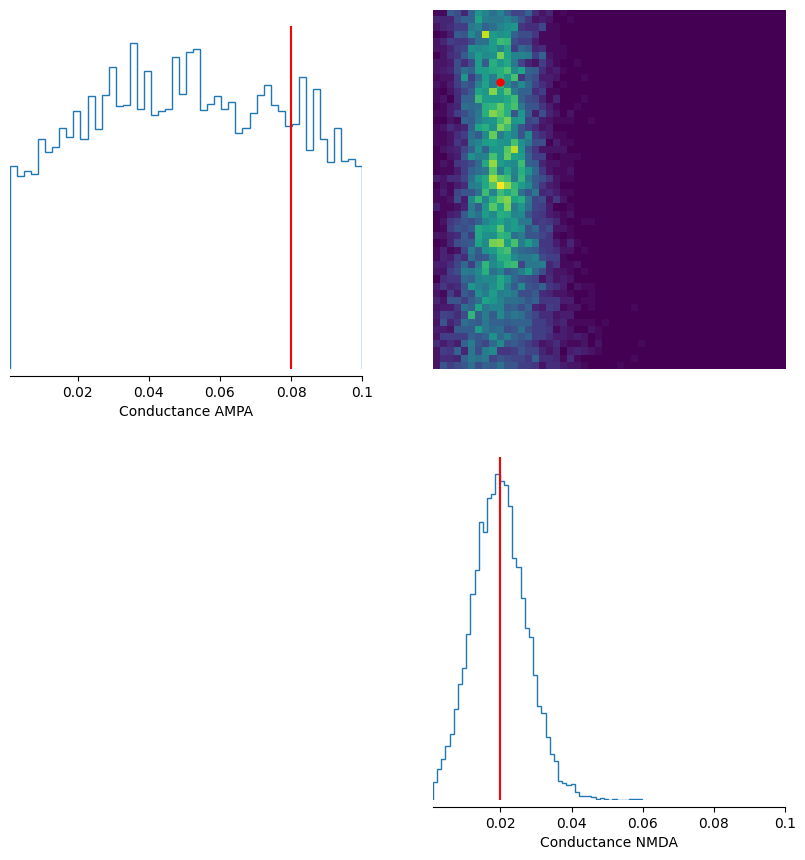

In [6]:
# --- LE NOUVEAU TEST CIBLE (AVEC MOYENNE AUSSI) ---
print("\n--- TEST SCIENTIFIQUE (MOYENNE DE 10 SWEEPS) ---")
vrai_ampa = 0.08
vrai_nmda = 0.02
print(f"Génération de l'expérience secrète (AMPA={vrai_ampa}, NMDA={vrai_nmda})...")

# On doit aussi moyenner la courbe cible pour que l'IA puisse comparer
sweeps_cible = []
for _ in range(10):
    t_cible, v_cible, ca_cible = jl.simuler_synapse_brute(vrai_ampa, vrai_nmda)
    t_fixe = np.linspace(float(t_cible[0]), float(t_cible[-1]), 500)
    v_fixe = np.interp(t_fixe, list(t_cible), list(v_cible))
    ca_fixe = np.interp(t_fixe, list(t_cible), list(ca_cible))
    sweeps_cible.append(np.concatenate([v_fixe, ca_fixe]))

courbe_cible_moyenne = torch.tensor(np.mean(sweeps_cible, axis=0), dtype=torch.float32)

print("L'IA tente de retrouver les valeurs secrètes...")
echantillons_devines = posterior.sample((10000,), x=courbe_cible_moyenne)

fig, axes = pairplot(
    echantillons_devines,
    limits=[[0.001, 0.1], [0.001, 0.1]], 
    labels=["Conductance AMPA", "Conductance NMDA"],
    points=[[vrai_ampa, vrai_nmda]], 
    points_colors=["red"]
)
plt.show()